# Greenhouse Energy Hub MPC — Results Analysis

Rolling-horizon economic MPC vs. a **limited-capability rule-based baseline** for a multi-carrier greenhouse energy hub. The baseline cannot dispatch hydrogen, charge the thermal store, or charge the battery from the grid, and has no look-ahead. Imported energy pays wholesale plus a transport/levy surcharge; exports earn wholesale.

The notebook loads the pinned IDs in `results/publication_manifest.json`, verifies every Run Bundle, and recomputes tables and plots from the bundle members. Regenerate publication artifacts with:
```bash
python3 experiments/publish_results.py --candidates results/diagnostics/publication-candidates.json --manifest results/publication_manifest.json
```

In [1]:
from pathlib import Path

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from greenhouse_energy_hub.evaluation import load_run_bundle, saving_percent, verify_run_bundle

ROOT = Path.cwd().resolve()
if not (ROOT / 'results').is_dir():
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
RUNS = RESULTS / 'runs'
publication = json.loads((RESULTS / 'publication_manifest.json').read_text(encoding='utf-8'))

def load_pinned_bundle(identifier):
    loaded = load_run_bundle(RUNS, identifier, repository_root=ROOT)
    bundle = verify_run_bundle(loaded.path, expected_identifier=identifier, repository_root=ROOT)
    trajectory = pd.read_csv(bundle.path / 'trajectory.csv', parse_dates=['timestamp_utc']).set_index('timestamp_utc')
    summary = json.loads((bundle.path / 'summary.json').read_text(encoding='utf-8'))
    return bundle, trajectory, summary

winter = publication['comparisons']['winter']
baseline_bundle, b, baseline_summary = load_pinned_bundle(winter['baseline_bundle_id'])
mpc_bundle, m, mpc_summary = load_pinned_bundle(winter['mpc_bundle_id'])
ablation_bundles = {name: load_pinned_bundle(identifier) for name, identifier in publication['ablations'].items()}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})
print(f'Loaded and verified {len(b)} winter operating steps from {baseline_bundle.identifier} and {mpc_bundle.identifier}.')

Loaded and verified 336 winter operating steps from 509c81dd1bea108aac1be2073b2b16646771bf65d5cc7f257081bcf81784713a and 1e9ee84ca78896c082b6d3216bab0d841f027b65f901aeec76bc78f253a90253.


## 1. Cost summary

Raw grid cost, **Inventory-Adjusted Cost**, and **Comfort Violation** are re-evaluated while verifying the pinned bundles; the notebook uses no mutable result CSV.

In [2]:
def nominal(summary, metric):
    return float(summary['nominal'][metric])

summary = pd.DataFrame([
    {'controller': 'limited-capability baseline', 'grid_cost_eur': nominal(baseline_summary, 'grid_cost_eur'), 'inventory_adjusted_cost_eur': nominal(baseline_summary, 'inventory_adjusted_cost_eur'), 'comfort_violation_c_h': nominal(baseline_summary, 'comfort_violation_c_h')},
    {'controller': 'MPC', 'grid_cost_eur': nominal(mpc_summary, 'grid_cost_eur'), 'inventory_adjusted_cost_eur': nominal(mpc_summary, 'inventory_adjusted_cost_eur'), 'comfort_violation_c_h': nominal(mpc_summary, 'comfort_violation_c_h')},
]).set_index('controller')
print(summary.round(1))
print(f"\nMPC saving: {saving_percent(nominal(baseline_summary, 'grid_cost_eur'), nominal(mpc_summary, 'grid_cost_eur')):+.1f}% (raw grid cost)   {saving_percent(nominal(baseline_summary, 'inventory_adjusted_cost_eur'), nominal(mpc_summary, 'inventory_adjusted_cost_eur')):+.1f}% (Inventory-Adjusted Cost)")

                             grid_cost_eur  inventory_adjusted_cost_eur  \
controller                                                                
limited-capability baseline        45307.9                      45389.0   
MPC                                42228.5                      42560.3   

                             comfort_violation_c_h  
controller                                          
limited-capability baseline                    0.0  
MPC                                            0.0  

MPC saving: +6.8% (raw grid cost)   +6.2% (Inventory-Adjusted Cost)


## 2. Cumulative cost
Cumulative grid cost is recomputed from the verified evaluation line items.

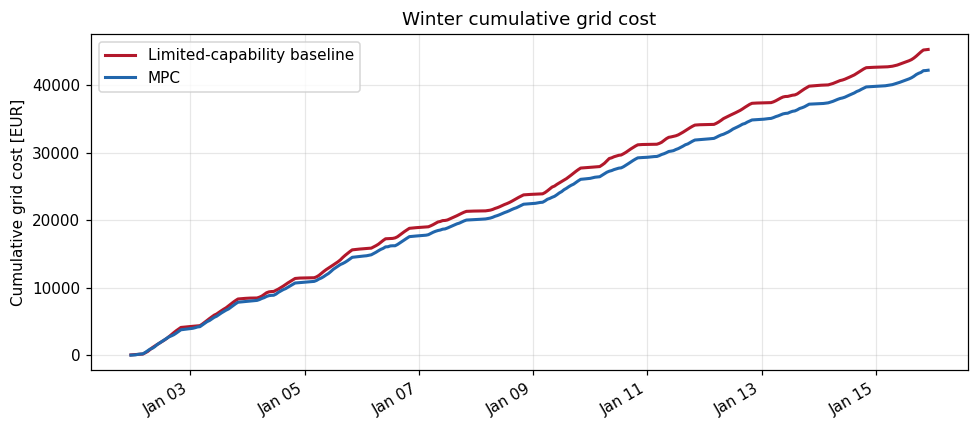

In [3]:
baseline_line_items = pd.DataFrame(baseline_summary['step_line_items'])
mpc_line_items = pd.DataFrame(mpc_summary['step_line_items'])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(b.index, baseline_line_items['grid_cost_eur'].cumsum(), label='Limited-capability baseline', lw=2, color='#b2182b')
ax.plot(m.index, mpc_line_items['grid_cost_eur'].cumsum(), label='MPC', lw=2, color='#2166ac')
ax.set_ylabel('Cumulative grid cost [EUR]')
ax.set_title('Winter cumulative grid cost')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

## 3. Grid exchange vs price
Negative grid power denotes export; both series are read from the verified winter MPC bundle.

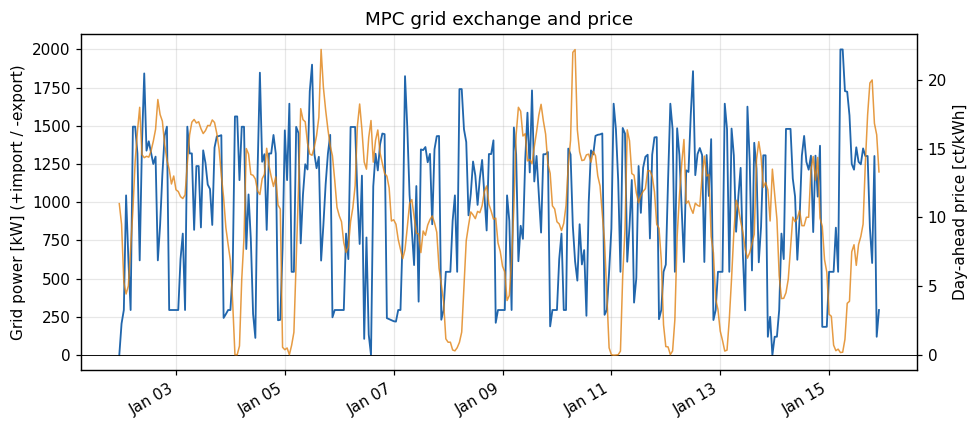

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m['grid_kw'], color='#2166ac', lw=1.2, label='MPC grid power [kW]')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Grid power [kW] (+import / -export)')
ax2 = ax.twinx()
ax2.plot(m.index, 100*m['price_eur_per_kwh'], color='#e08214', lw=1.0, alpha=0.8)
ax2.set_ylabel('Day-ahead price [ct/kWh]'); ax2.grid(False)
ax.set_title('MPC grid exchange and price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout(); plt.show()

## 4. State-of-charge trajectories
The trajectories below are recomputed from the two pinned winter comparison bundles.

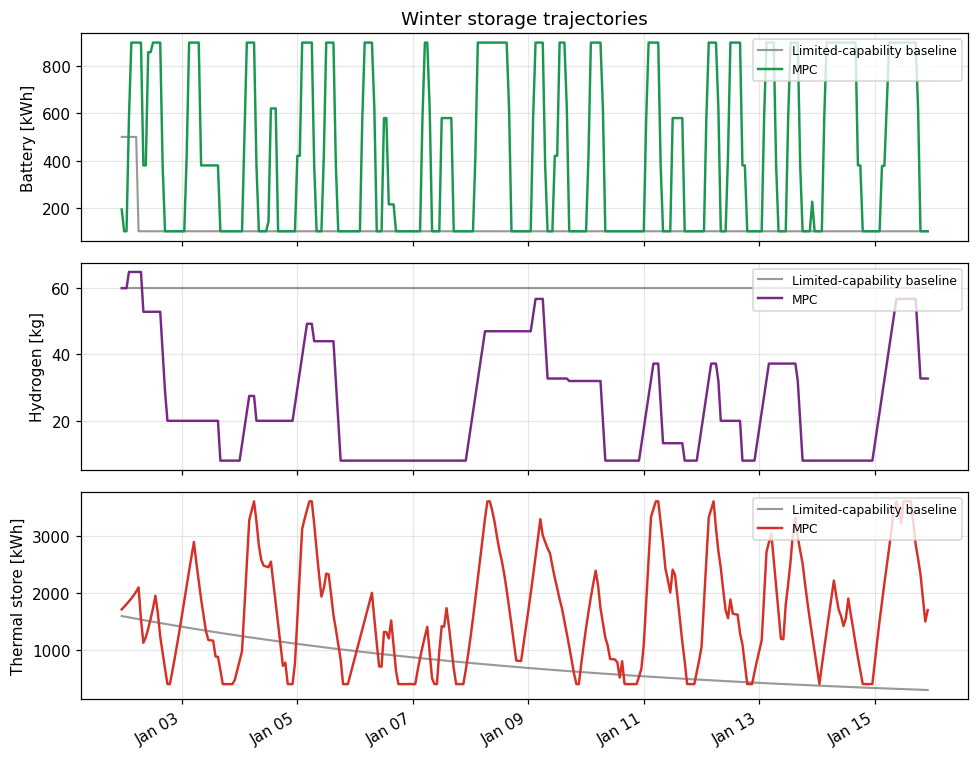

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, col, lab, color in zip(axs, ['reached_soc_battery_kwh', 'reached_soc_hydrogen_kg', 'reached_soc_thermal_kwh'], ['Battery [kWh]', 'Hydrogen [kg]', 'Thermal store [kWh]'], ['#1a9850', '#762a83', '#d73027']):
    ax.plot(b.index, b[col], label='Limited-capability baseline', lw=1.4, color='grey', alpha=0.8)
    ax.plot(m.index, m[col], label='MPC', lw=1.6, color=color)
    ax.set_ylabel(lab); ax.legend(loc='upper right', fontsize=8)
axs[0].set_title('Winter storage trajectories')
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout(); plt.show()

## 5. Greenhouse temperature
The verified trajectories show the indoor temperature alongside the [16, 24] °C comfort band. The limited-capability baseline targets the lower bound reactively.

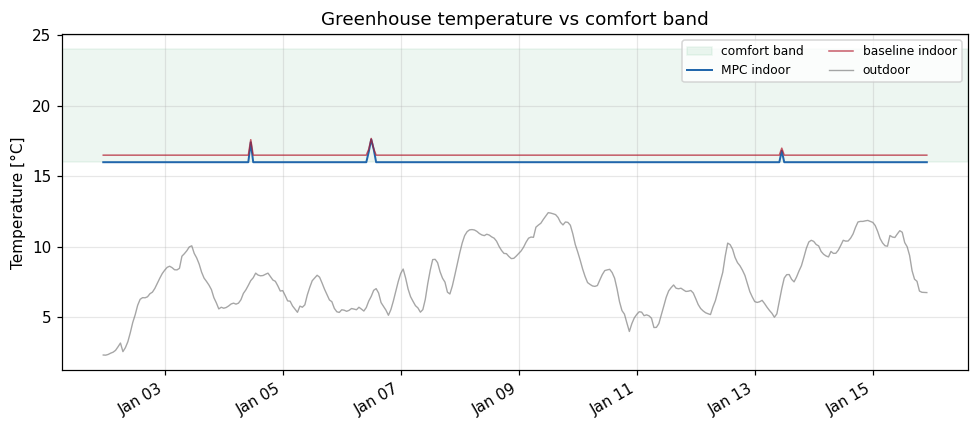

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(16, 24, color='#1a9850', alpha=0.08, label='comfort band')
ax.plot(m.index, m['reached_indoor_temperature_c'], color='#2166ac', lw=1.3, label='MPC indoor')
ax.plot(b.index, b['reached_indoor_temperature_c'], color='#b2182b', lw=1.0, alpha=0.7, label='baseline indoor')
ax.plot(m.index, m['outdoor_temperature_c'], color='grey', lw=0.9, alpha=0.7, label='outdoor')
ax.set_ylabel('Temperature [°C]'); ax.set_title('Greenhouse temperature vs comfort band')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout(); plt.show()

## 6. Flexible heat: e-boiler load-shifting
The verified MPC trajectory provides the electric-boiler, heat-pump, thermal-store, and price series.

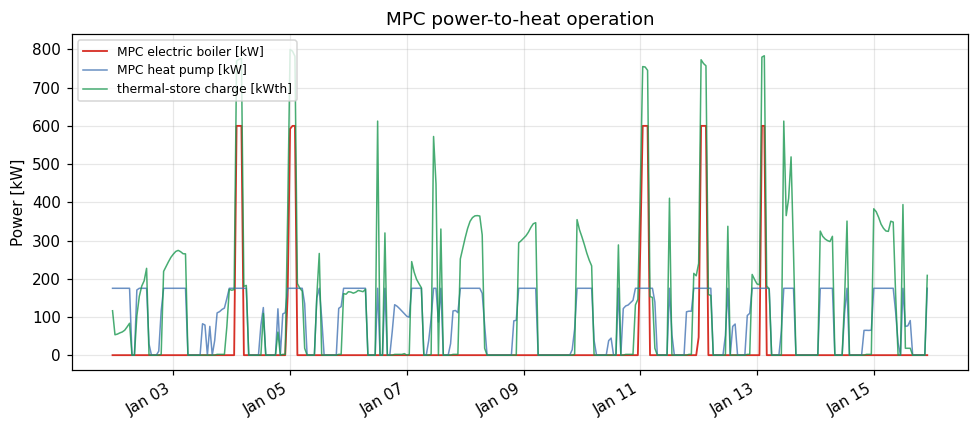

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m['electric_boiler_kw'], color='#d73027', lw=1.2, label='MPC electric boiler [kW]')
ax.plot(m.index, m['heat_pump_kw'], color='#4575b4', lw=1.0, alpha=0.8, label='MPC heat pump [kW]')
ax.plot(m.index, m['thermal_charge_kw'], color='#1a9850', lw=1.0, alpha=0.8, label='thermal-store charge [kWth]')
ax.set_ylabel('Power [kW]')
ax.set_title('MPC power-to-heat operation'); ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout(); plt.show()

## 7. Verified winter ablations
Each value is recomputed from its pinned Run Bundle. Inventory-Adjusted Cost and Comfort Violation remain separate measures.

         variant                                                        bundle_id  inventory_adjusted_cost_eur  comfort_violation_c_h  cost_change_vs_full_pct
      MPC (full) 9c0b37e82655b6ccef9e1b1d831ee729d37eb4afc289a78045bab85fbe287e4a                 42560.263928               0.000000                 0.000000
           no H₂ 9b36719b929fffcef26084f5efa37bcb2385b9b9199c7e429dec37a86993ad97                 43057.333780               0.000000                -1.167920
no thermal store 787abda250b5b2f47005452322aa8d65ee5c7bcb8848246797e4e98ea8e1b8de                 43302.604230               0.000000                -1.744210
one-step horizon df487e8da6980b2d87c7629ee276d92952630f0feebfb6962d2b291838edc5ac                 41081.897211            2826.446123                 3.473584


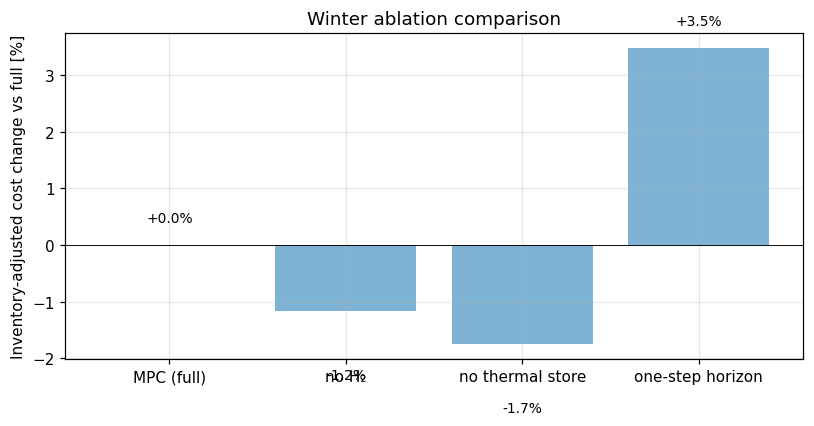

In [8]:
ablation_order = [('MPC (full)', 'full'), ('no H₂', 'no-h2'), ('no thermal store', 'no-tes'), ('one-step horizon', 'one-step')]
full_cost = nominal(ablation_bundles['full'][2], 'inventory_adjusted_cost_eur')
abl = pd.DataFrame([
    {'variant': label, 'bundle_id': ablation_bundles[key][0].identifier, 'inventory_adjusted_cost_eur': nominal(ablation_bundles[key][2], 'inventory_adjusted_cost_eur'), 'comfort_violation_c_h': nominal(ablation_bundles[key][2], 'comfort_violation_c_h')}
    for label, key in ablation_order
])
abl['cost_change_vs_full_pct'] = abl['inventory_adjusted_cost_eur'].map(lambda cost: saving_percent(full_cost, cost))
print(abl.to_string(index=False))
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(abl['variant'], abl['cost_change_vs_full_pct'], color=['#2166ac'] + ['#7fb3d5'] * (len(abl) - 1))
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Inventory-adjusted cost change vs full [%]')
ax.set_title('Winter ablation comparison')
for bar, value in zip(bars, abl['cost_change_vs_full_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + (0.4 if value >= 0 else -1.2), f'{value:+.1f}%', ha='center', fontsize=9)
fig.tight_layout(); plt.show()

## Takeaways

- Every table and plot above was recomputed after loading and verifying the full IDs pinned in `publication_manifest.json`.
- The comparison reports Inventory-Adjusted Cost and Comfort Violation separately.
- The ablation table includes the full Run Bundle identifier for every variant; the README cites those identifiers for its causal statements.
- These are simulation-prototype results under the named Evaluation Policy.